# Importamos lo necesario para comenzar

In [ ]:
import os
import glob
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import csv
from tensorflow.keras.preprocessing.image import ImageDataGenerator
!pip install -q kaggle

pip install -U numpy scikit-image
import numpy as np
from skimage.feature import graycomatrix, graycoprops

# Para el punto 3

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc)

print(np.__version__)

2.0.2


# Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip -d /content/chest_xray


base_path = "/content/chest_xray/chest_xray/"

print("Carpetas encontradas:", os.listdir(base_path))

print("Train:", os.listdir(base_path + "train"))
print("Test:", os.listdir(base_path + "test"))
print("Val:", os.listdir(base_path + "val"))

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: /content/chest_xray/chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inf

# Analisis exploratorio y Preprocesamiento

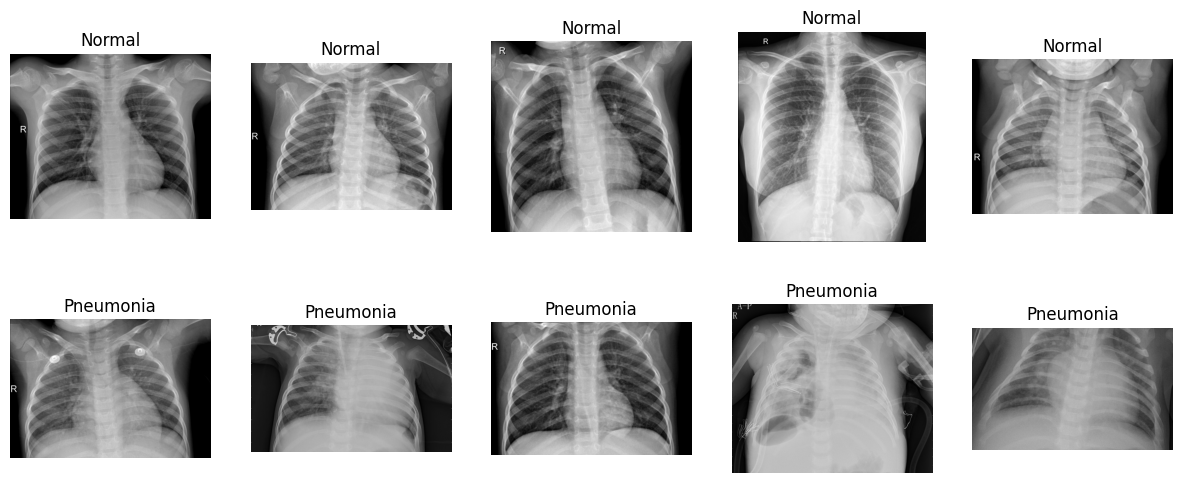

In [ ]:
train_Normal = os.path.join(base_path, "train/NORMAL")
train_Pneu   = os.path.join(base_path, "train/PNEUMONIA")

normal_Imgs = os.listdir(train_Normal)
pneu_Imgs   = os.listdir(train_Pneu)

# Visualizamos 5 imagenes distintas de manera aleatoria
fig, ax = plt.subplots(2, 5, figsize=(15,6))

normal_list = []
pneumonia_list = []

for i in range(5):

    random_Normal = random.randint(0, len(normal_Imgs)-1)
    img_n = Image.open(os.path.join(train_Normal, normal_Imgs[random_Normal]))
    normal_list.append(img_n)
    ax[0,i].imshow(img_n, cmap='gray')
    ax[0,i].axis('off')
    ax[0,i].set_title("Normal")

    random_Pneu = random.randint(0, len(pneu_Imgs)-1)
    img_p = Image.open(os.path.join(train_Pneu, pneu_Imgs[random_Pneu]))
    pneumonia_list.append(img_p)
    ax[1,i].imshow(img_p, cmap='gray')
    ax[1,i].axis('off')
    ax[1,i].set_title("Pneumonia")

plt.show()

In [ ]:
for split in ["train", "test", "val"]:
    normal = len(os.listdir(base_path + f"{split}/NORMAL"))
    pneu   = len(os.listdir(base_path + f"{split}/PNEUMONIA"))
    print(f"{split.upper()} -> Normal: {normal}, Pneumonia: {pneu}")

def get_sizes(path):
  size = []
  files = os.listdir(path)
  for i in files:
    img = Image.open(os.path.join(path, i))
    size.append(img.size)
    img.close()
  return np.array(size)

train_normal = os.path.join(base_path, "train/NORMAL")
train_pneu   = os.path.join(base_path, "train/PNEUMONIA")

sizes_normal = get_sizes(train_normal)
sizes_pneu   = get_sizes(train_pneu)

normal_Mean =  sizes_normal.mean(axis=0)
pneu_Mean =  sizes_pneu.mean(axis=0)

normal_Std =  sizes_normal.std(axis=0)
pneu_Std =  sizes_pneu.std(axis=0)

print(f"La media de normal es: {normal_Mean}")
print(f"La media de pneumonia es: {pneu_Mean}")

print(f"La desviacion estandar de normal es: {normal_Std}")
print(f"La desviacion estandar de pneumonia es {pneu_Std}")

TRAIN -> Normal: 1341, Pneumonia: 3875
TEST -> Normal: 234, Pneumonia: 390
VAL -> Normal: 8, Pneumonia: 8
La media de normal es: [1667.73452647 1381.43102163]
La media de pneumonia es: [1200.4836129   825.02683871]
La desviacion estandar de normal es: [289.10265845 326.1990408 ]
La desviacion estandar de pneumonia es [291.26808567 277.03800471]


# Preprocesamiento

<Figure size 640x480 with 0 Axes>

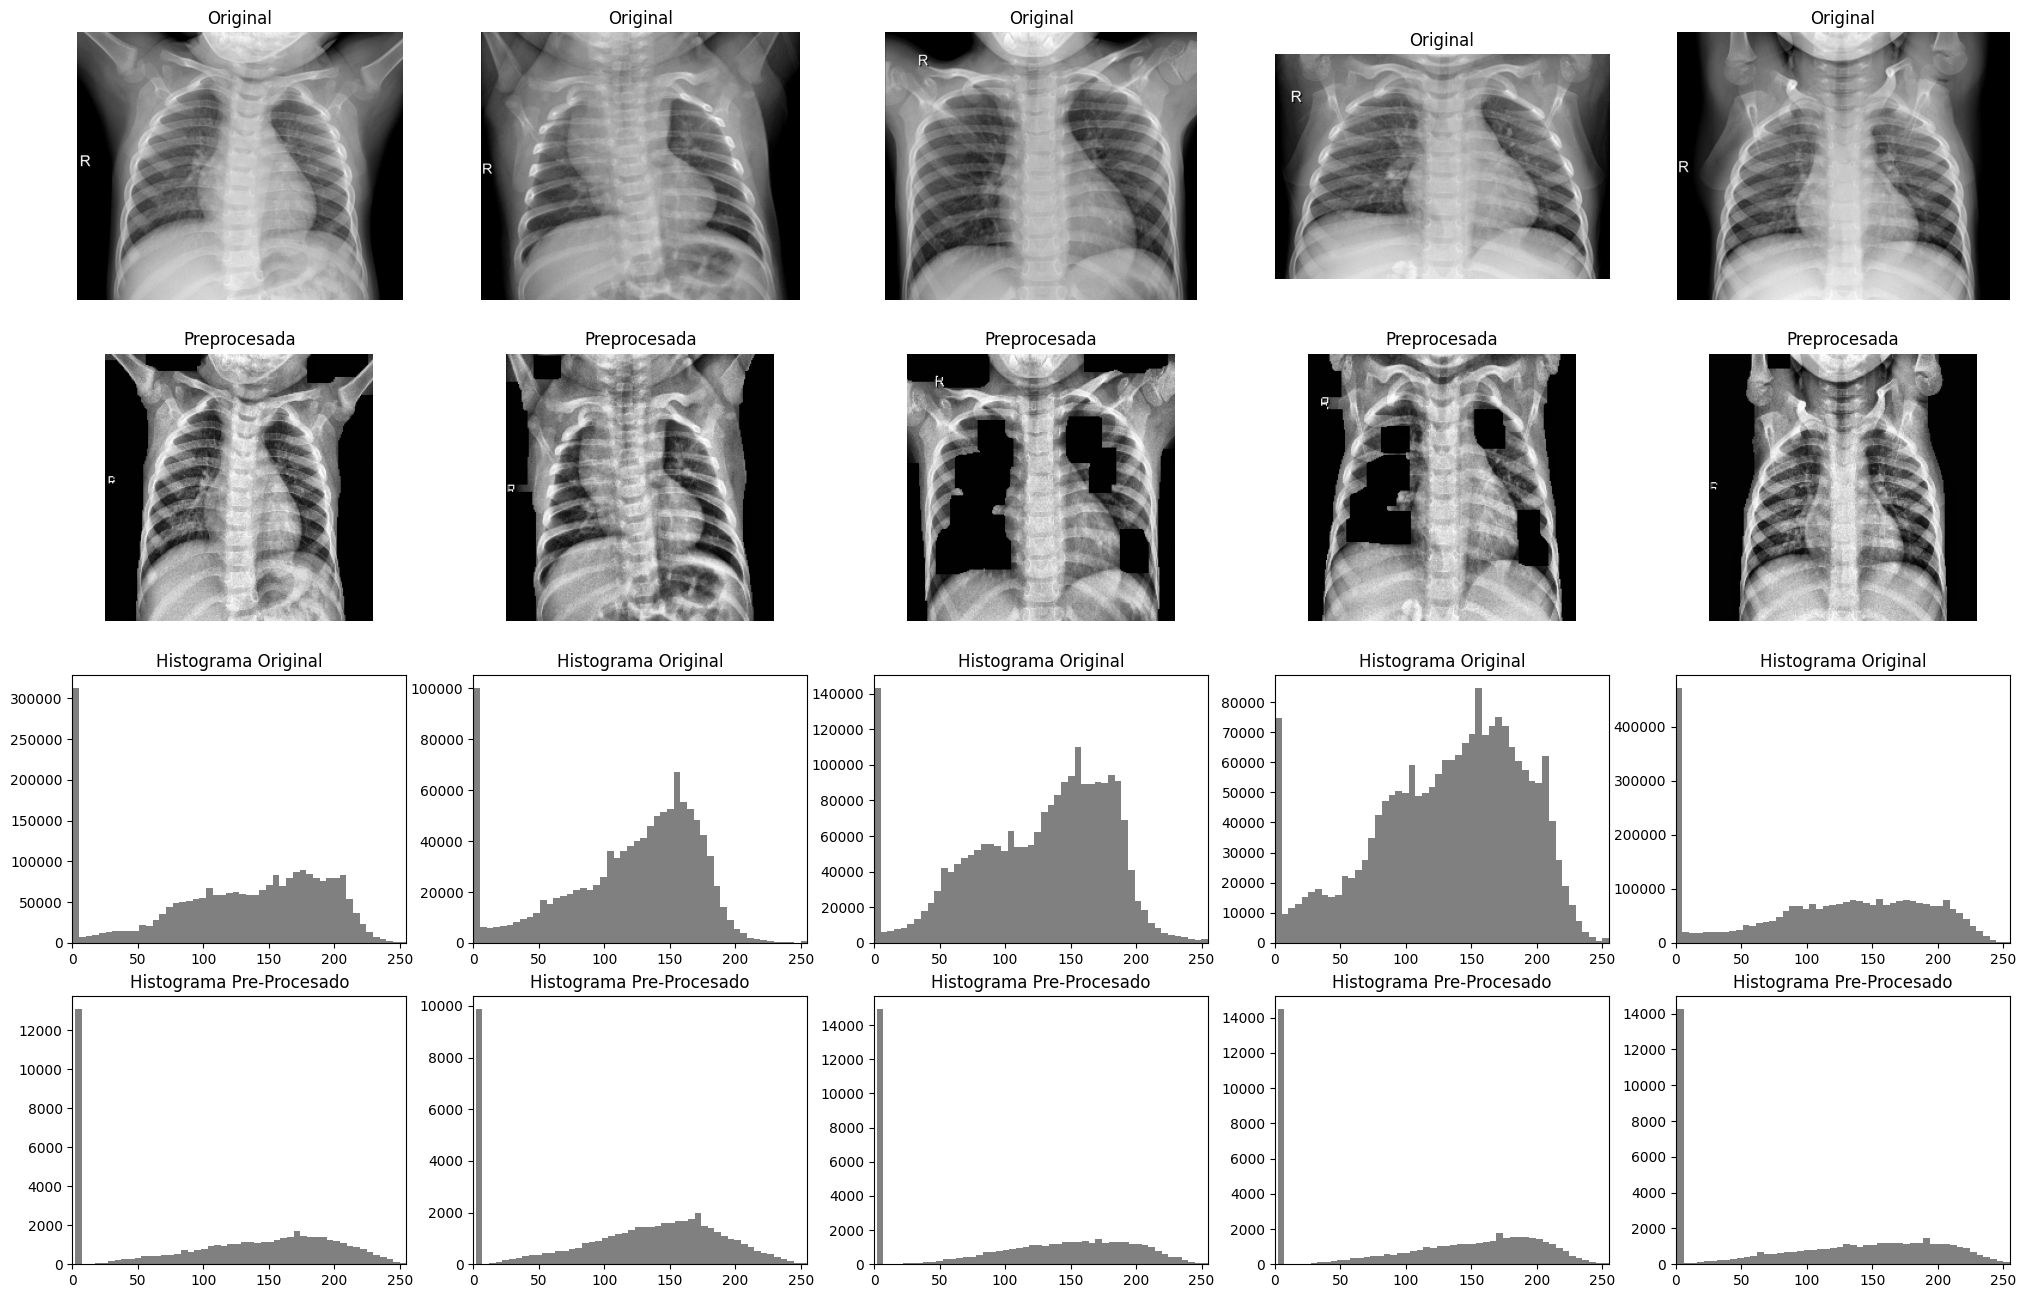

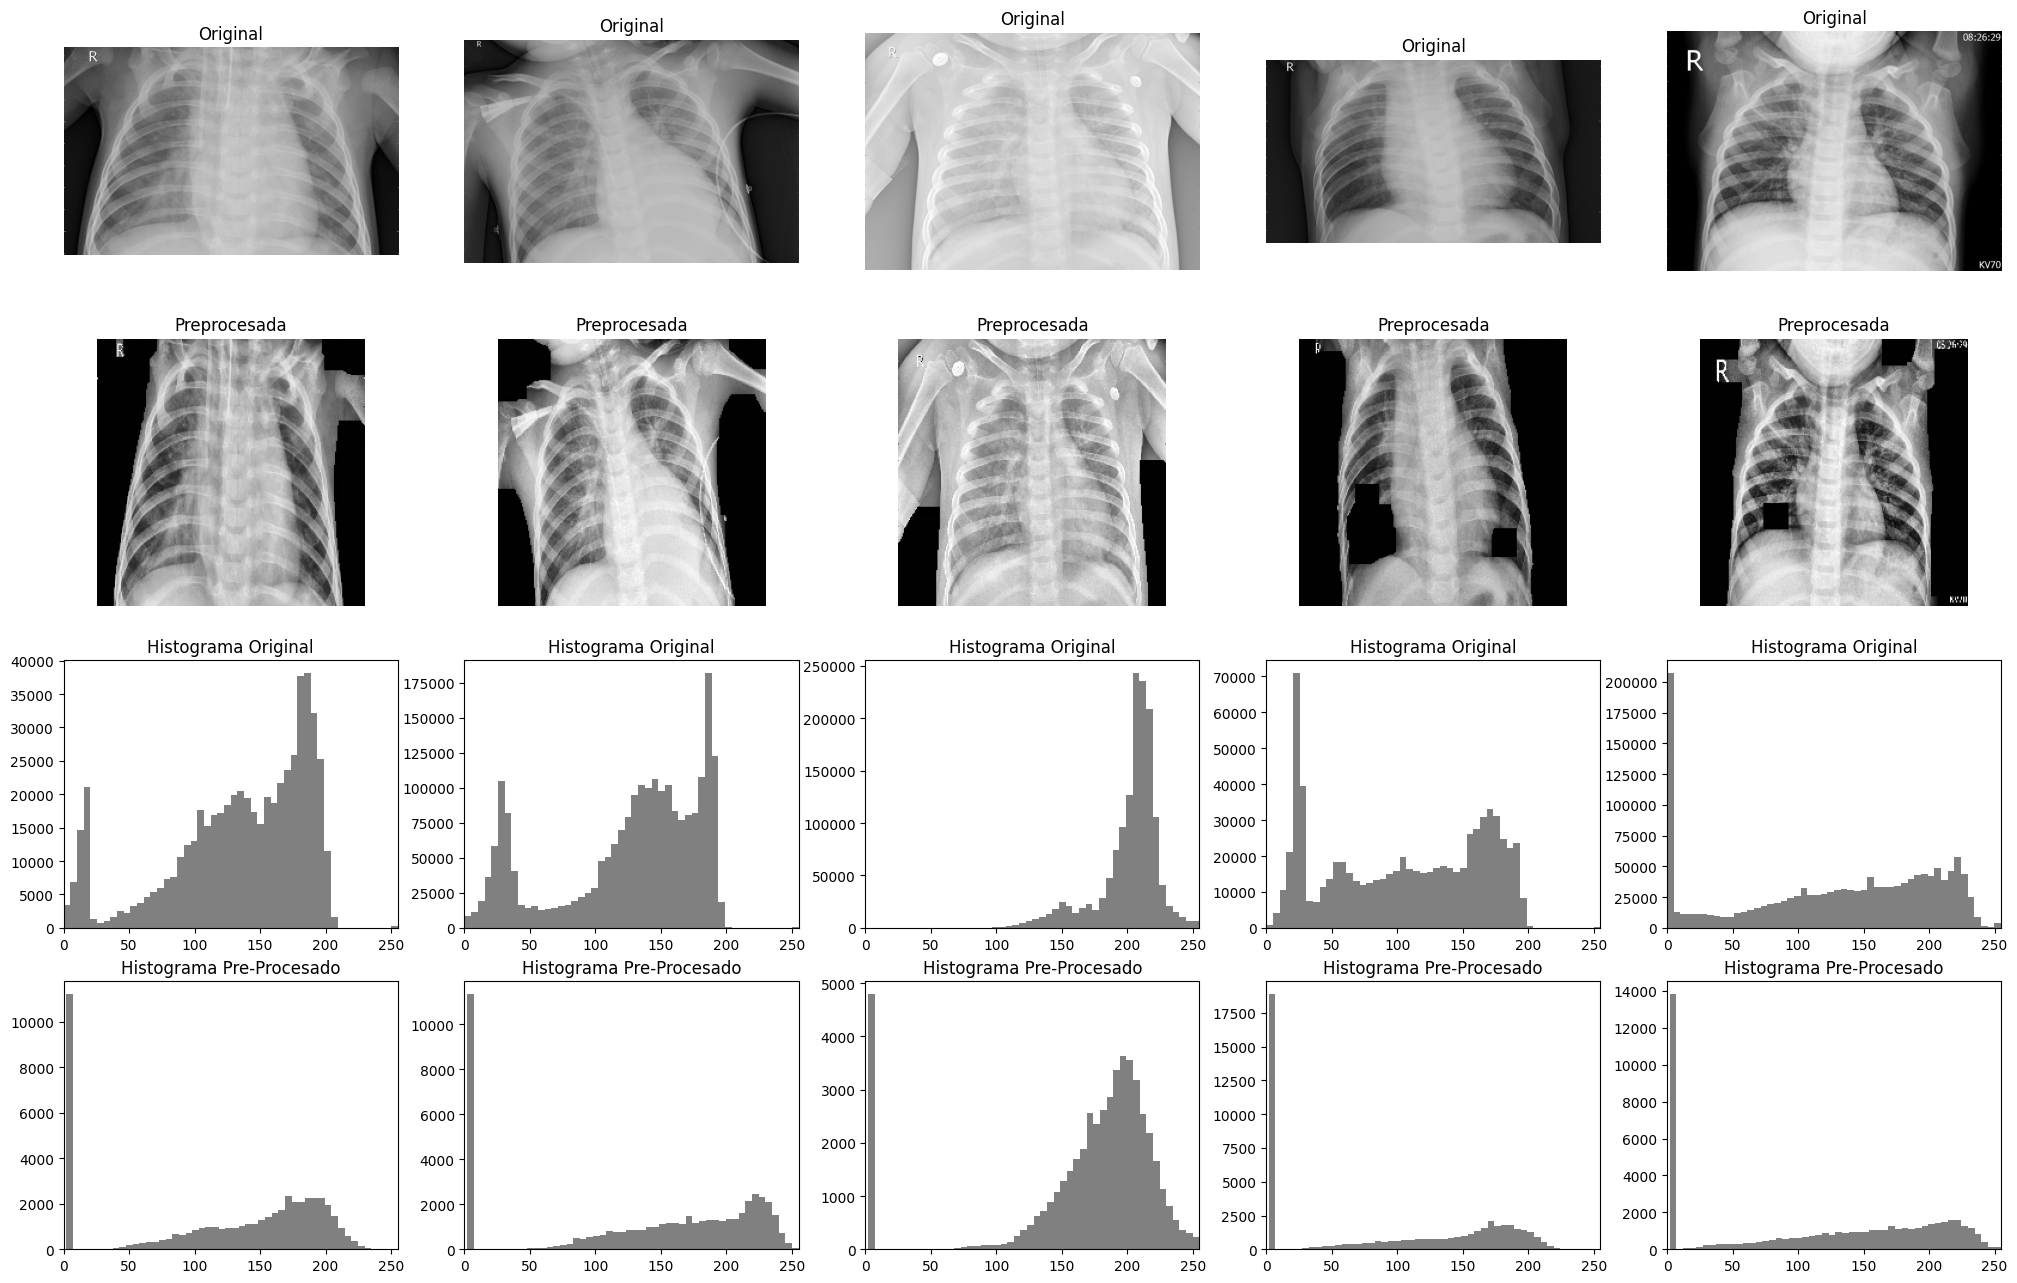

In [ ]:
# Redimensionar las imagenes

new_Size = 224

def resize_Img(img):
    return cv2.resize(img, (new_Size, new_Size))

# Segmentacion

def segment(img):

    # Suavizado para eliminar ruido
    blur = cv2.GaussianBlur(img, (5,5), 0)

    # Umbral automático (Otsu)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if np.mean(img[mask == 255]) < np.mean(img[mask == 0]):
        mask = cv2.bitwise_not(mask)

    # Morfología: cerrar huecos dentro de la máscara
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Aplicar la máscara a la imagen original
    segmented = cv2.bitwise_and(img, img, mask=mask)

    # Normalizar para asegurar pulmones blancos
    img_Segmented = cv2.normalize(segmented, None, 0, 255, cv2.NORM_MINMAX)

    return img_Segmented

# CLAHE (Ecualización adaptativa)

def apply_Clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)

def process_Img(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = resize_Img(img)
    img = segment(img)
    img = apply_Clahe(img)
    img = img.astype("float32") / 255.0
    return img

# Visualizacion de un set de imagenes.

def view_Imgs(train_Pattern, imgs_types, img_num):
  fig, ax = plt.subplots(4, img_num, figsize=(25, 16))

  for i in range(img_num):

    # seleccionar imagen aleatoria
    random_idx = random.randint(0, len(imgs_types)-1)
    img_path = os.path.join(train_Pattern, imgs_types[random_idx])

    # cargar original
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # aplicar tu pipeline completo
    img_proc = process_Img(img_path)
    proc_plot = (img_proc * 255).astype(np.uint8)

    # Original
    ax[0, i].imshow(img, cmap='gray')
    ax[0, i].axis('off')
    ax[0, i].set_title("Original")

    # Preprocesada
    ax[1, i].imshow(img_proc, cmap='gray')
    ax[1, i].axis('off')
    ax[1, i].set_title("Preprocesada")

    # Histograma Original
    ax[2, i].hist(img.ravel(), bins=50, color='gray')
    ax[2, i].set_xlim(0, 255)
    ax[2, i].set_title("Histograma Original")

    # Histograma Pre-procesado
    ax[3, i].hist(proc_plot.ravel(), bins=50, color='gray')
    ax[3, i].set_xlim(0, 255)
    ax[3, i].set_title("Histograma Pre-Procesado")

plt.tight_layout()
plt.show()

view_Imgs(train_Normal, normal_Imgs, 5)
view_Imgs(train_Pneu, pneu_Imgs, 5)

# Parte 2: Extracción de Descriptores Clásicos

# Descriptorees de Forma: Fourier Shape Descriptors

Descriptores de Fourier para imagen (N=20):
Índice |         Real |   Imaginario |   Magnitud | Fase (rad)
------------------------------------------------------------
     1 |      0.95145 |     -0.30779 |    1.00000 |   -0.31287
     2 |     -0.75527 |     -0.62227 |    0.97860 |   -2.45245
     3 |      0.27411 |     -0.91555 |    0.95571 |   -1.27990
     4 |     -1.15321 |      0.13495 |    1.16108 |    3.02510
     5 |     -0.18982 |     -0.28945 |    0.34614 |   -2.15123
     6 |      0.15052 |     -0.17466 |    0.23057 |   -0.85951
     7 |     -0.32499 |     -0.01713 |    0.32545 |   -3.08893
     8 |     -0.16874 |     -0.38361 |    0.41908 |   -1.98521
     9 |     -0.01841 |     -0.11541 |    0.11687 |   -1.72898
    10 |      0.16076 |     -0.01124 |    0.16115 |   -0.06979
    11 |      0.07476 |      0.02570 |    0.07906 |    0.33107
    12 |     -0.07125 |      0.07943 |    0.10670 |    2.30200
    13 |     -0.07025 |     -0.05735 |    0.09069 |   -2.45692
    14 |     

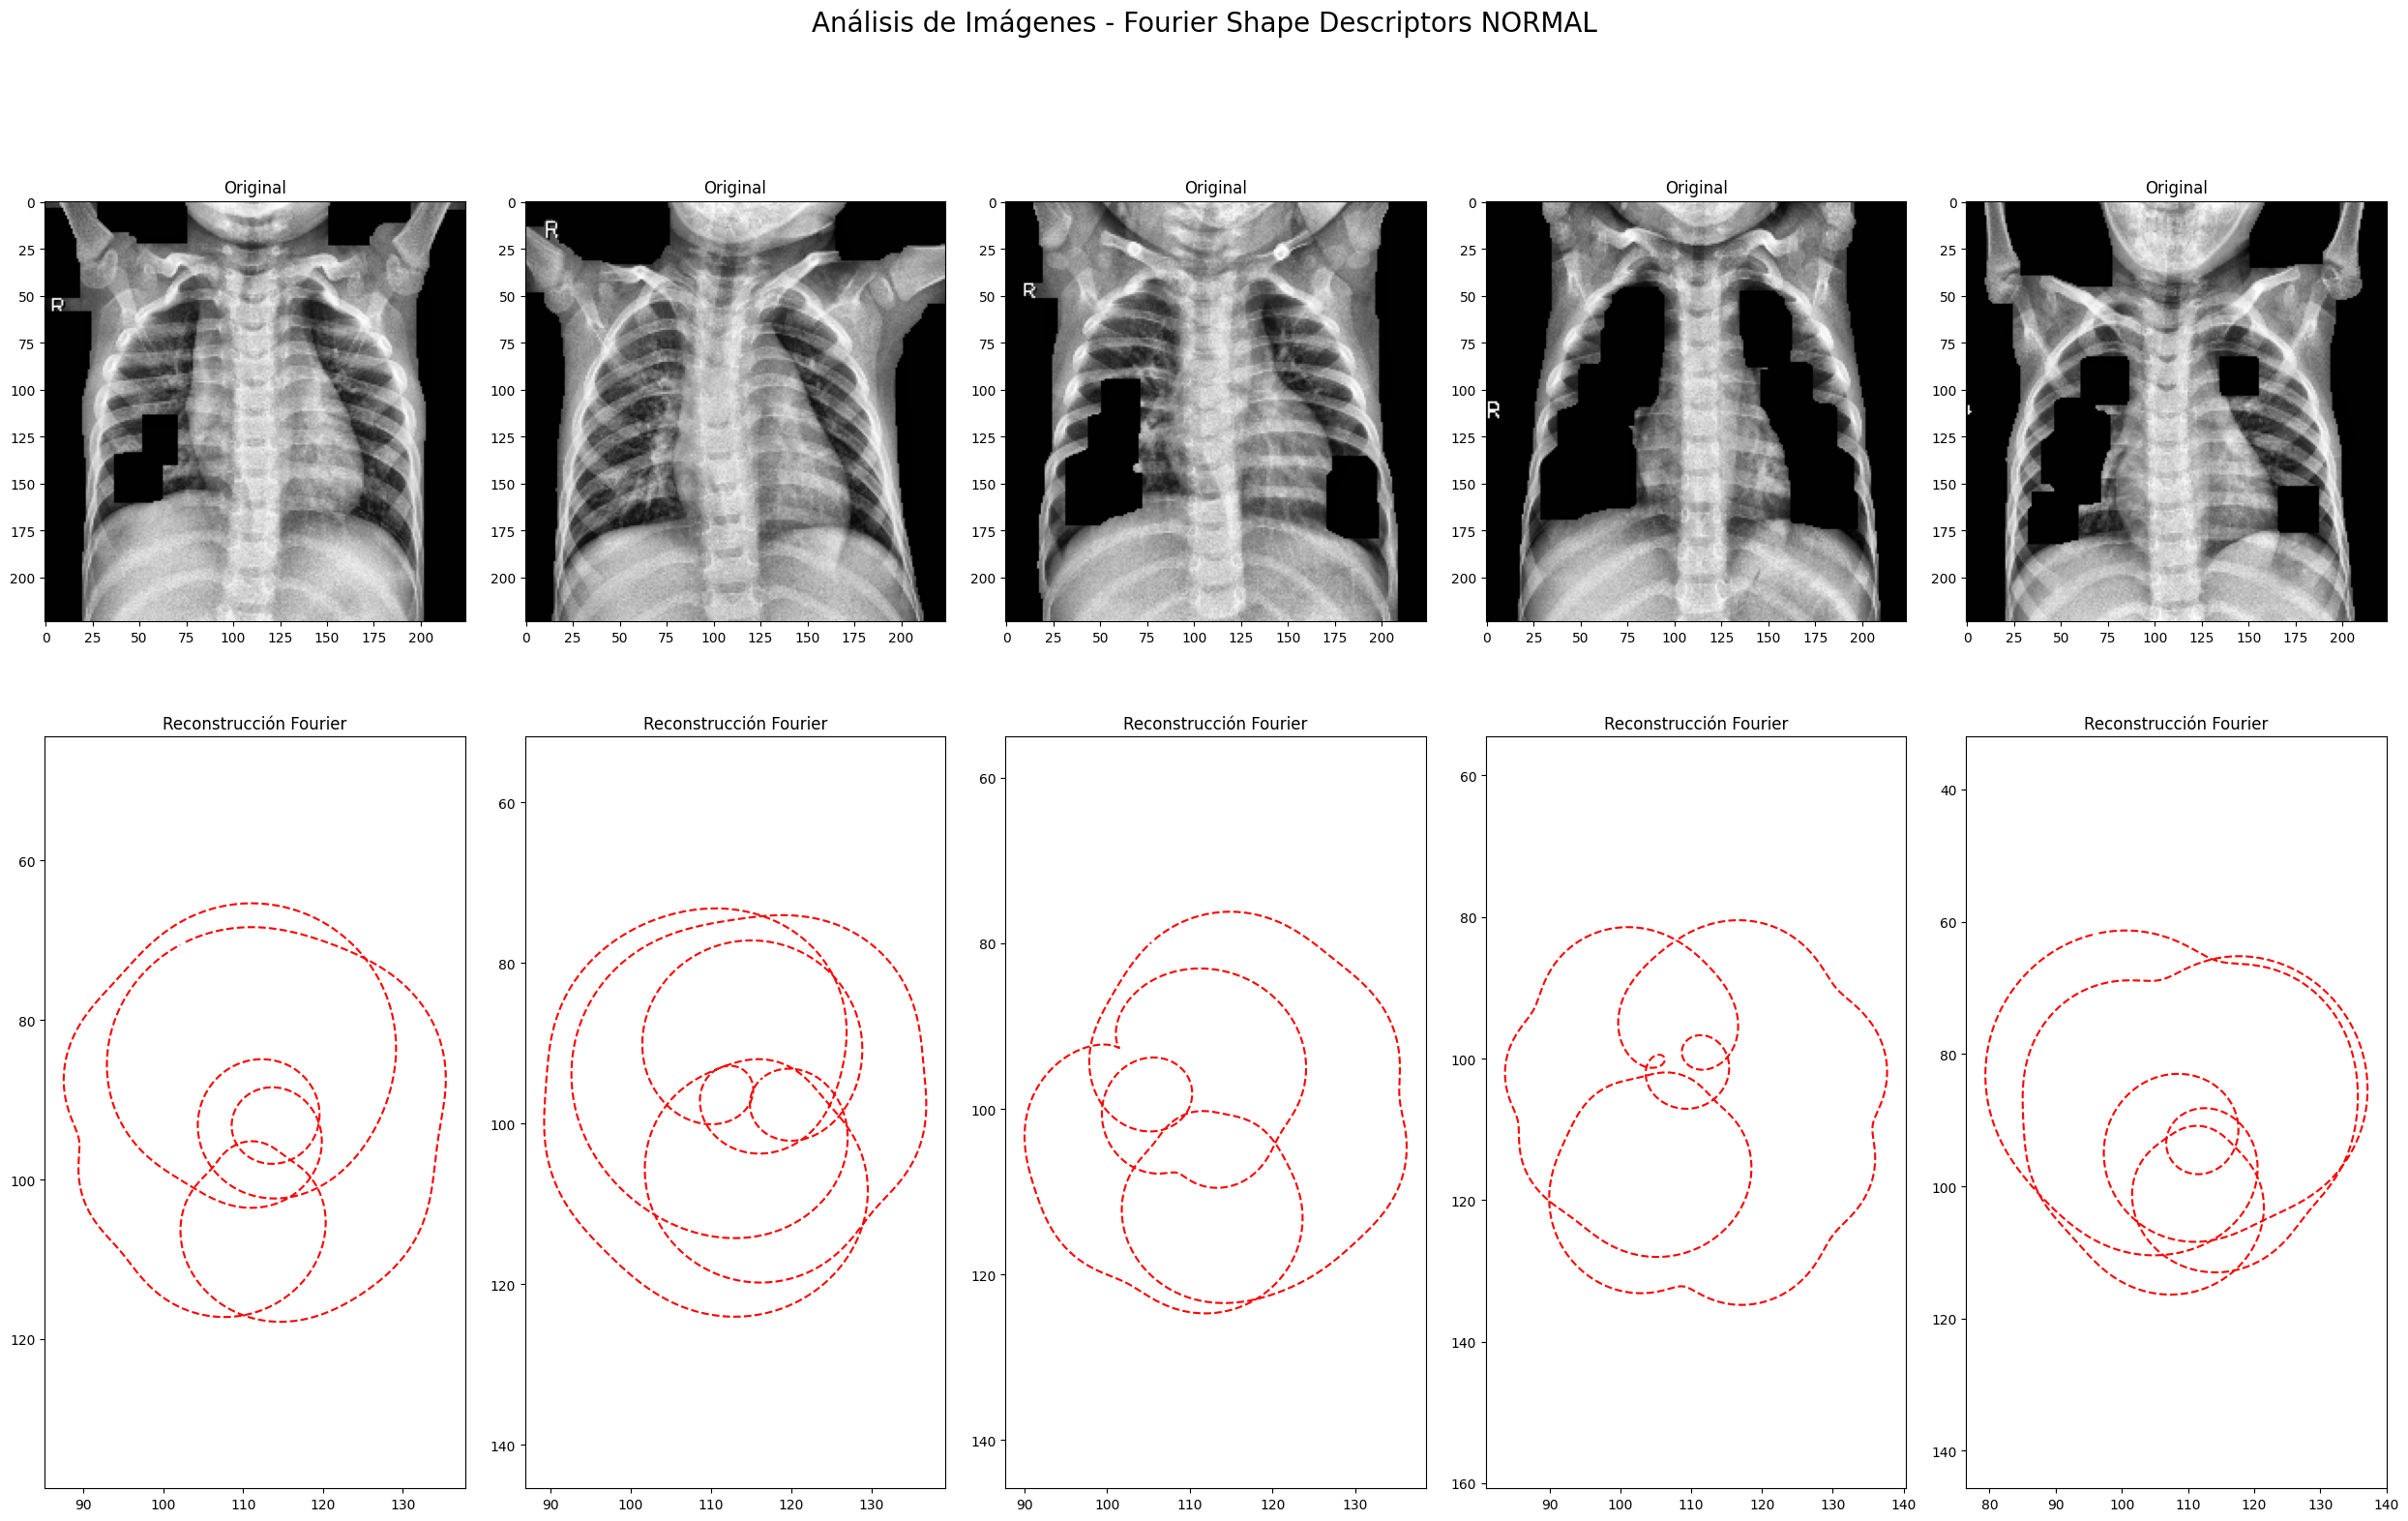

Descriptores de Fourier para imagen (N=20):
Índice |         Real |   Imaginario |   Magnitud | Fase (rad)
------------------------------------------------------------
     1 |      0.64920 |      0.76062 |    1.00000 |    0.86427
     2 |     -0.98534 |      0.86876 |    1.31364 |    2.41899
     3 |     -0.66158 |     -0.23367 |    0.70164 |   -2.80207
     4 |      0.51684 |      0.46248 |    0.69355 |    0.72995
     5 |     -0.11806 |     -0.20701 |    0.23831 |   -2.08913
     6 |     -0.48068 |      0.25926 |    0.54614 |    2.64696
     7 |      0.00182 |     -0.23596 |    0.23596 |   -1.56310
     8 |      0.10884 |      0.19448 |    0.22286 |    1.06058
     9 |     -0.19102 |      0.02654 |    0.19285 |    3.00353
    10 |      0.11137 |      0.02208 |    0.11354 |    0.19570
    11 |      0.09840 |     -0.09250 |    0.13505 |   -0.75450
    12 |      0.03327 |     -0.01739 |    0.03754 |   -0.48166
    13 |      0.00528 |      0.03953 |    0.03988 |    1.43811
    14 |     

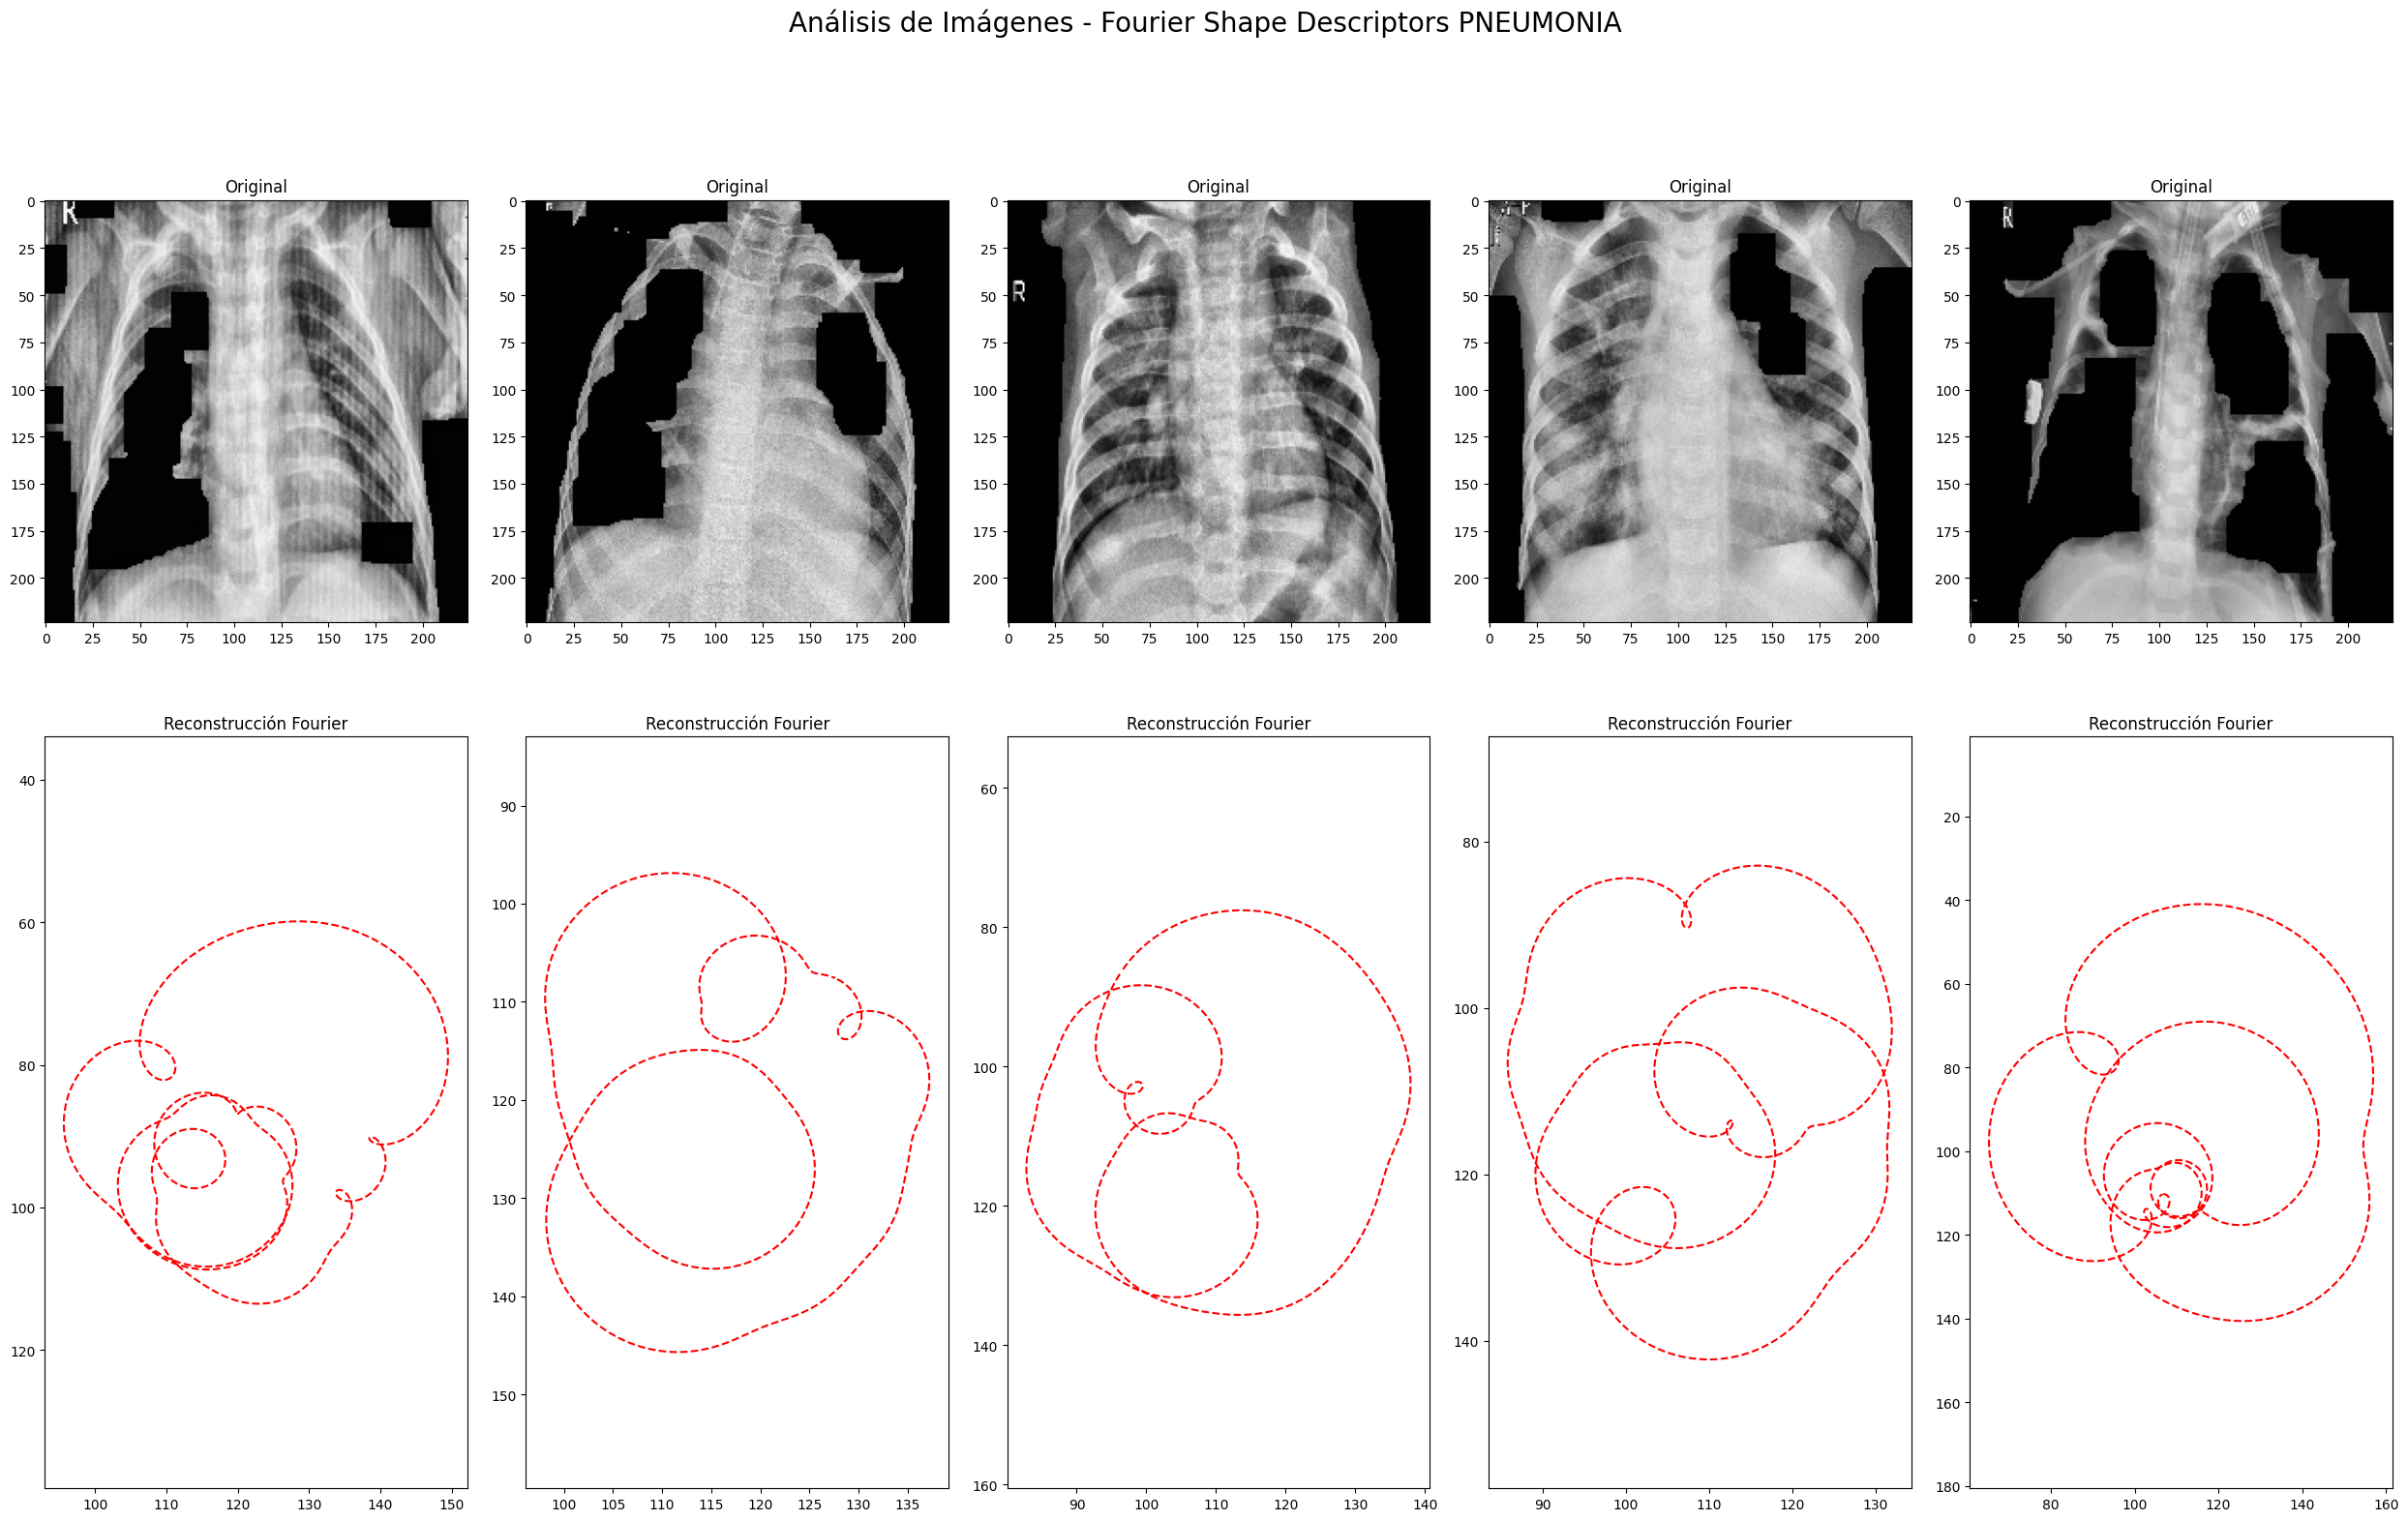

CSV saved at: /content/fourier_normal.csv
CSV saved at: /content/fourier_pneu.csv


In [ ]:
# Aplicamos Fourier para obtener frecuencias de contorno

def fourier_shape_descriptor(img, n=20):
    # Obtener contornos
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if len(contours) == 0:
        return None

    contour = max(contours, key=cv2.contourArea).squeeze()

    # Representar como números complejos
    z = contour[:,0] + 1j * contour[:,1]

    # FFT
    Z = np.fft.fft(z)

    # Normalizar (evita dependencia de escala y traslación)
    Z = Z / np.abs(Z[1])

    # Tomar los primeros N coeficientes (omitimos Z[0])
    descriptors = Z[1:n+1]

    return descriptors

def fourier_reconstruction(z, N):
    Z = np.fft.fft(z)
    Z_f = np.zeros_like(Z)
    Z_f[:N] = Z[:N]
    z_rec = np.fft.ifft(Z_f)
    return z_rec

def print_descriptors(desc, img_name=None):
    if desc is None:
        print(f"No se encontraron descriptores para la imagen {img_name}")
        return

    print(f"Descriptores de Fourier para {img_name if img_name else 'imagen'} (N={len(desc)}):")
    print(f"{'Índice':>6} | {'Real':>12} | {'Imaginario':>12} | {'Magnitud':>10} | {'Fase (rad)':>10}")
    print("-" * 60)
    for i, c in enumerate(desc, 1):
        real = c.real
        imag = c.imag
        mag = abs(c)
        phase = np.angle(c)
        print(f"{i:6d} | {real:12.5f} | {imag:12.5f} | {mag:10.5f} | {phase:10.5f}")
    print("-" * 60)

def process_Img_Fourier(train_Pattern, imgs_types, img_num, n):
  fig, ax = plt.subplots(2, img_num, figsize=(25, 16))

  if(train_Pattern == train_Normal):
    name = "NORMAL"
  elif(train_Pattern == train_Pneu):
    name = "PNEUMONIA"

  for i in range(img_num):

    # Seleccionar imagen aleatoria
    random_idx = random.randint(0, len(imgs_types)-1)
    img_path = os.path.join(train_Pattern, imgs_types[random_idx])

    # Cargar y procesarla
    img = process_Img(img_path)
    img = (img * 255).astype(np.uint8)

    # Binarización para encontrar contorno
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Obtener contorno más grande
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
      continue

    contour = max(contours, key=cv2.contourArea).squeeze()
    z = contour[:,0] + 1j * contour[:,1]

    # Obtener descriptores
    desc = fourier_shape_descriptor(thresh, n)

    # Reconstrucción para visualización
    z_rec = fourier_reconstruction(z, n)

    # Original
    ax[0, i].imshow(img, cmap='gray')
    ax[0, i].set_title("Original")

    # Graficar contorno reconstruido
    ax[1,i].plot(z_rec.real, z_rec.imag, 'r--')
    ax[1,i].invert_yaxis()
    ax[1,i].set_title("Reconstrucción Fourier")
    ax[1,i].axis('equal')

    print_descriptors(desc, i)
  fig.suptitle(f"Análisis de Imágenes - Fourier Shape Descriptors {name}", fontsize=20)
  plt.tight_layout()
  plt.show()

process_Img_Fourier(train_Normal, normal_Imgs, 5, 20)
process_Img_Fourier(train_Pneu, pneu_Imgs, 5, 20)

# Save as a CSV

# Descriptor a un vector
def desc_to_vector(desc):
    if desc is None:
        return None
    vec = []
    for c in desc:
        vec.append(c.real)
        vec.append(c.imag)
    return vec

def save_Fourier_csv(train_path, img_list, label, n, csv_writer):
    for img_name in img_list:
        img_path = os.path.join(train_path, img_name)

        img = process_Img(img_path)
        img = (img * 255).astype(np.uint8)

        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        desc = fourier_shape_descriptor(thresh, n)
        vec = desc_to_vector(desc)

        if vec is None:
            continue
        csv_writer.writerow([img_name, label] + vec)

def create_fourier_csv(train_path, img_list, label, csv_path, n=20):
    header = ["filename", "label"]  # ADD filename to header
    for i in range(1, n+1):
        header += [f"f{i}_real", f"f{i}_imag"]

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)

        save_Fourier_csv(train_path, img_list, label, n, writer)

    print(f"CSV saved at: {csv_path}")


csv_normal_path = "/content/fourier_normal.csv"
csv_pneu_path = "/content/fourier_pneu.csv"

create_fourier_csv(train_Normal, normal_Imgs, "NORMAL", csv_normal_path, n=20)
create_fourier_csv(train_Pneu, pneu_Imgs, "PNEUMONIA", csv_pneu_path, n=20)




# Descriptor de textura GLCM


Imagen seleccionada: /content/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1026-0001.jpeg
Dist=1 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=0.79 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=2.36 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=0.79 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=2.36 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=4 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=4 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogen

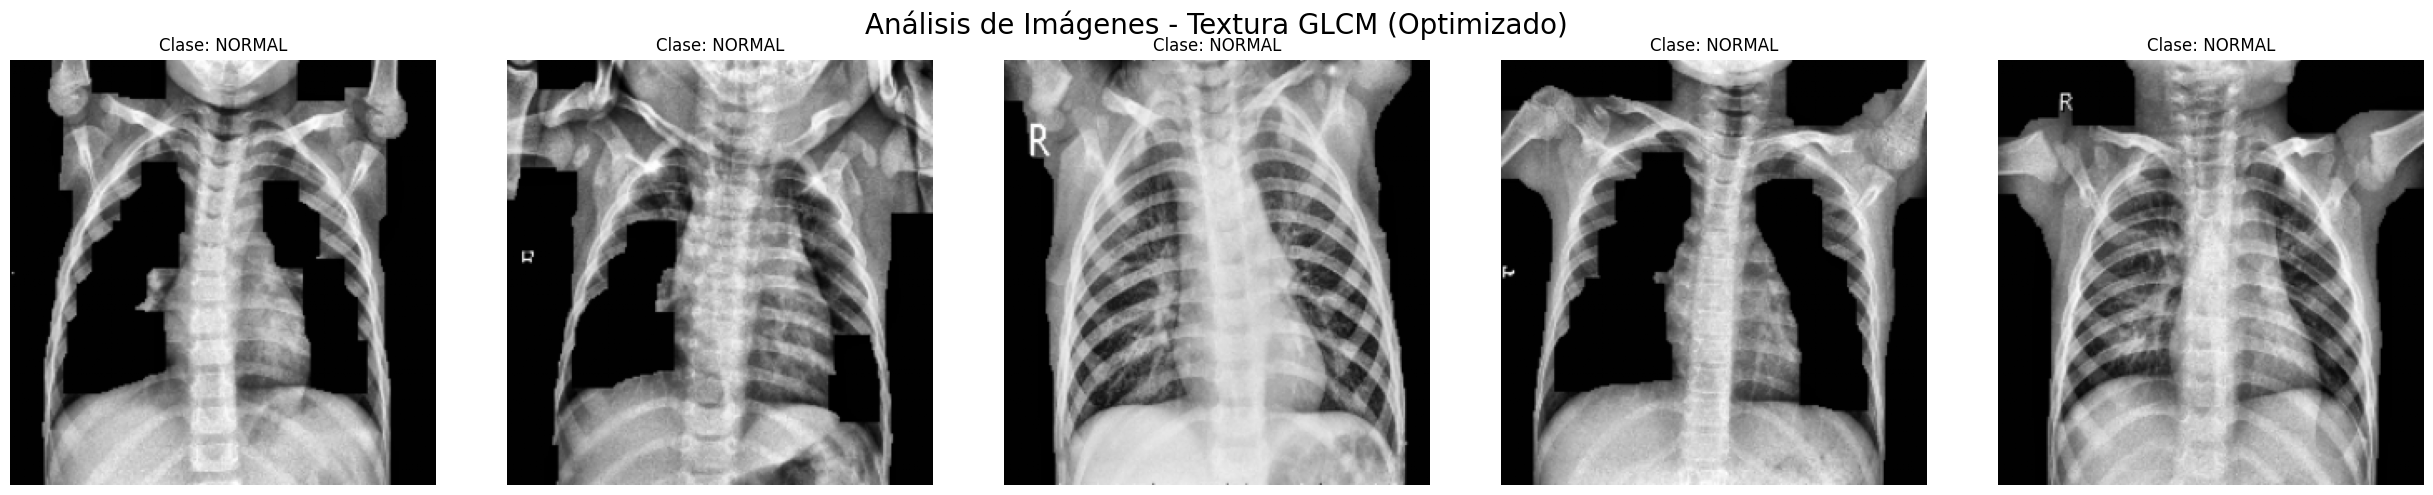


Imagen seleccionada: /content/chest_xray/chest_xray/train/PNEUMONIA/person472_bacteria_2015.jpeg
Dist=1 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=0.79 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=1 ang=2.36 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=0.79 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=2 ang=2.36 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=4 ang=0.00 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, Homogeneidad: 1.00
Dist=4 ang=1.57 -> Contraste: 0.00, Correlación: 1.00, Energía: 1.00000, H

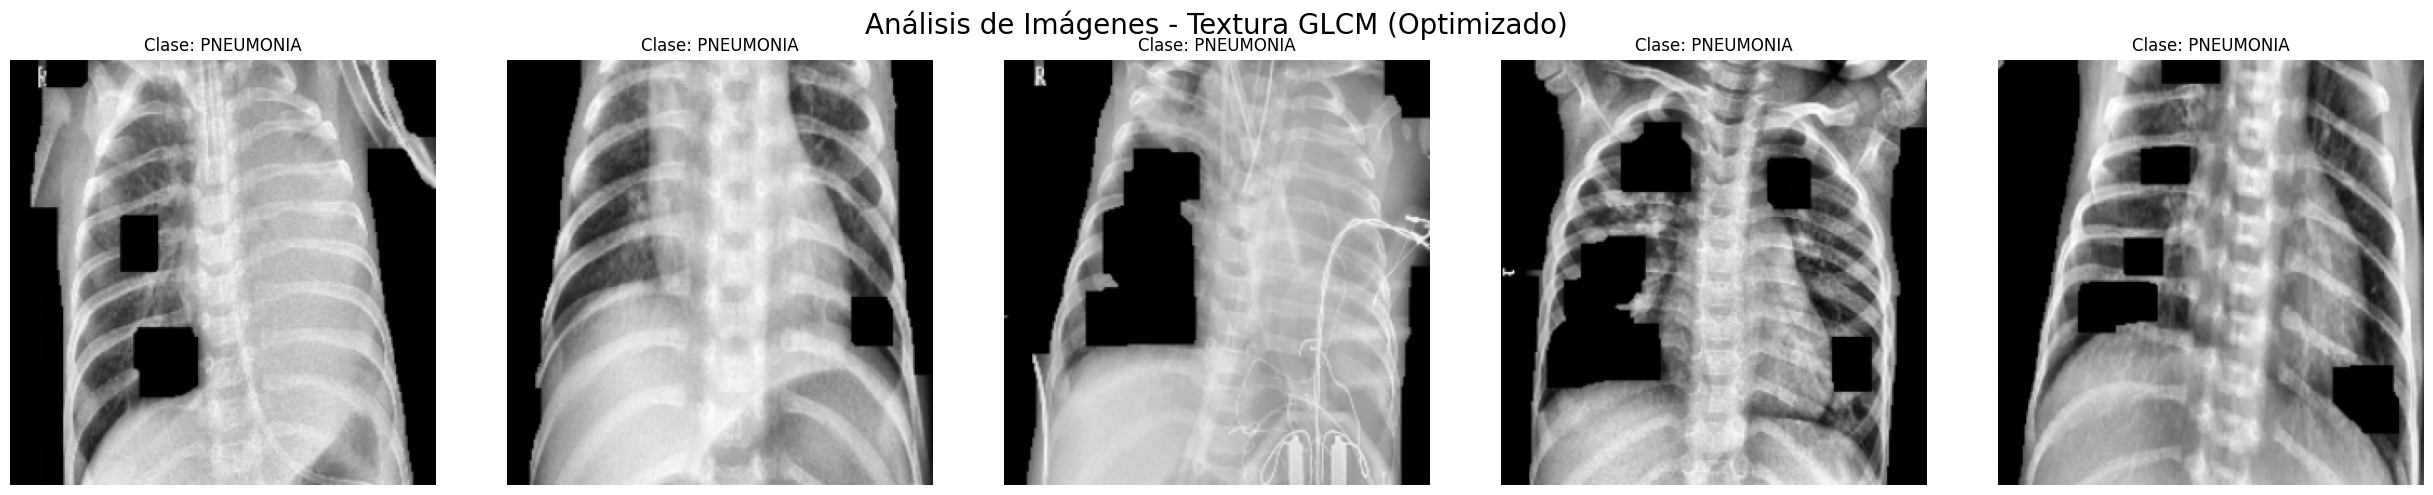

CSV generado correctamente: /content/glcm_normal.csv
CSV generado correctamente: /content/glcm_pneu.csv


In [ ]:
# Parámetros
# Distancias y direcciones (en radianes)
distances = [1, 2, 4]
angles = [0, np.pi/2, np.pi/4, 3*np.pi/4]  # 0°, 90°, 45°, 135°

# Reducción de niveles para acelerar
levels = 16

# Función rápida para obtener GLCM
def get_glcm_features(img, distances, angles, levels=16):

    # Reducir niveles de gris
    img_small = (img // (256 // levels)).astype(np.uint8)
    resultados = []

    for d in distances:
        glcm = graycomatrix(img_small,
                            distances=[d],
                            angles=angles,
                            levels=levels,
                            symmetric=True,
                            normed=True)
        for idx, angle in enumerate(angles):
            resultados.append({
                "distancia": d,
                "angulo_rad": angle,
                "contraste": graycoprops(glcm, 'contrast')[0, idx],
                "correlacion": graycoprops(glcm, 'correlation')[0, idx],
                "energia": graycoprops(glcm, 'energy')[0, idx],
                "homogeneidad": graycoprops(glcm, 'homogeneity')[0, idx]
            })
    return resultados

# Función para mostrar imágenes aleatorias con GLCM
def analize_random_glcm(dataset_dir, classes, distances, angles, img_num=5):
    # Obtener lista de imágenes
    imgs = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    # Seleccionar aleatoriamente
    imgs_random = random.sample(imgs, min(img_num, len(imgs)))

    # Crear subplots en 1 fila
    fig, ax = plt.subplots(1, len(imgs_random), figsize=(25, 5))  # 25 ancho, 5 alto
    if len(imgs_random) == 1:
        ax = [ax]  # asegurar iterable si solo hay 1 imagen

    for i, img_path in enumerate(imgs_random):
        # Cargar imagen
        img = process_Img(img_path)
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (256, 256))

        # Extraer features
        features = get_glcm_features(img, distances, angles, levels)

        # Mostrar imagen
        ax[i].imshow(img, cmap='gray')
        ax[i].set_title(f"Clase: {os.path.basename(os.path.dirname(img_path))}")
        ax[i].axis("off")

        # Imprimir en consola
        print(f"\nImagen seleccionada: {img_path}")
        for f in features:
            print(
                f"Dist={f['distancia']} ang={f['angulo_rad']:.2f} -> "
                f"Contraste: {f['contraste']:.2f}, "
                f"Correlación: {f['correlacion']:.2f}, "
                f"Energía: {f['energia']:.5f}, "
                f"Homogeneidad: {f['homogeneidad']:.2f}"
            )

    fig.suptitle("Análisis de Imágenes - Textura GLCM (Optimizado)", fontsize=20)
    plt.tight_layout()
    plt.show()


analize_random_glcm(train_normal, ["NORMAL"], distances, angles)
analize_random_glcm(train_pneu, ["PNEUMONIA"], distances, angles)

# Función para generar CSV del dataset completo
def dataset_csv_fast(dataset_dir, classes, distances, angles, salida_csv="glcm_dataset_fast.csv"):
    rows = []
    folder = os.path.join(dataset_dir)
    for filename in os.listdir(folder):
            if not filename.lower().endswith(('.jpg','.jpeg','.png')):
                continue
            path = os.path.join(folder, filename)
            img = process_Img(path)
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            #img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (256, 256))
            features = get_glcm_features(img, distances, angles, levels)
            for f in features:
                row = {"filename": filename, "label": classes, **f}
                rows.append(row)

    # Guardar CSV
    keys = rows[0].keys()
    with open(salida_csv, "w", newline="") as f:
        dict_writer = csv.DictWriter(f, keys)
        dict_writer.writeheader()
        dict_writer.writerows(rows)

    print(f"CSV generado correctamente: {salida_csv}")

dataset_csv_fast(train_normal, "NORMAL", distances, angles, salida_csv="/content/glcm_normal.csv")
dataset_csv_fast(train_pneu, "PNEUMONIA", distances, angles, salida_csv="/content/glcm_pneu.csv")


## Basado en:
Le Mercier, A. (2025). All Best Tabular Classifiers - Comparative Study [Cuaderno de código]. Kaggle. https://www.kaggle.com/code/alexandrelemercier/all-best-tabular-classifiers-comparative-study

# Parte 3: Clasificación con Descriptores Clásicos

1. Crear matriz de características para todo el dataset
2. Normalización de features (StandardScaler, MinMaxScaler)

In [ ]:
from sklearn.svm import SVC

# Cargar datasets
fourier_normal = pd.read_csv("fourier_normal.csv")
fourier_pneu = pd.read_csv("fourier_pneu.csv")

glcm_normal = pd.read_csv("glcm_normal.csv")
glcm_pneu = pd.read_csv("glcm_pneu.csv")

# Combinar normal y neumonía
fourier_data = pd.concat([fourier_normal, fourier_pneu], axis=0, ignore_index=True)
glcm_data = pd.concat([glcm_normal, glcm_pneu], axis=0, ignore_index=True)

# Dataset combinado Fourier + GLCM
normal_combined = pd.merge(fourier_normal, glcm_normal, on=["filename","label"], how="inner")
pneu_combined = pd.merge(fourier_pneu, glcm_pneu, on=["filename","label"], how="inner")
combined_data = pd.concat([normal_combined, pneu_combined], axis=0, ignore_index=True)

# Diccionario para iterar
datasets = {"Fourier": fourier_data, "GLCM": glcm_data, "Combinado": combined_data}

# Entrenar con SVM

def train_evaluate_svm(df, name_dataset):
    print(f"{name_dataset}")

    X = df.drop(columns=["filename","label"])
    y = df["label"]

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Escalar los datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Selección de features
    #selector = SelectKBest(f_classif, k=20)
    selector = SelectKBest(f_classif, k=min(20, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected  = selector.transform(X_test_scaled)

    # Entrenar SVM
    svm = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
    svm.fit(X_train_selected, y_train)

    # Predicción
    y_pred = svm.predict(X_test_selected)
    y_scores = svm.predict_proba(X_test_selected)[:,1]

    # Métricas
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, pos_label='PNEUMONIA'):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, pos_label='PNEUMONIA'):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred, pos_label='PNEUMONIA'):.4f}\n")

    print("Classification Report")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {name_dataset}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # Curva ROC
    y_binary = y_test.map({"NORMAL":0, "PNEUMONIA":1})
    fpr, tpr, _ = roc_curve(y_binary, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2, color="blue")
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.title(f"Curva ROC - {name_dataset}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"AUC: {roc_auc:.4f}\n")

    # Escalar todo el dataset
    X_scaled = scaler.fit_transform(X)

    # SVM
    #svm = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
    svm_linear = LinearSVC(C=1.0, max_iter=5000, random_state=42)

    # Validación cruzada 5-fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(svm_linear, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

    print("Validación cruzada 5 folds - Accuracy por fold:", cv_scores)
    print("Promedio:", cv_scores.mean())





===== Combinado =====



/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [42 43 44 45] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy : 0.9087
Precision: 0.9047
Recall   : 0.9804
F1-score : 0.9410

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.93      0.70      0.80      3219
   PNEUMONIA       0.90      0.98      0.94      9300

    accuracy                           0.91     12519
   macro avg       0.92      0.84      0.87     12519
weighted avg       0.91      0.91      0.90     12519



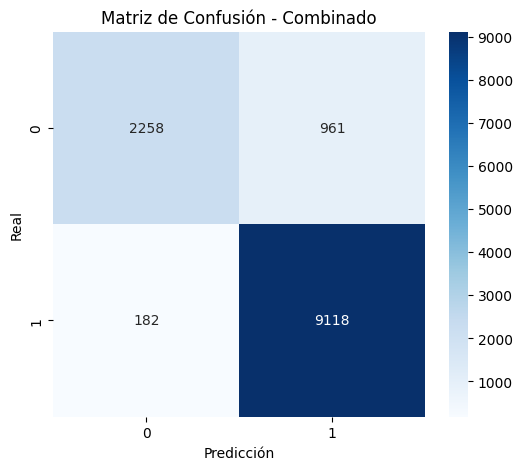

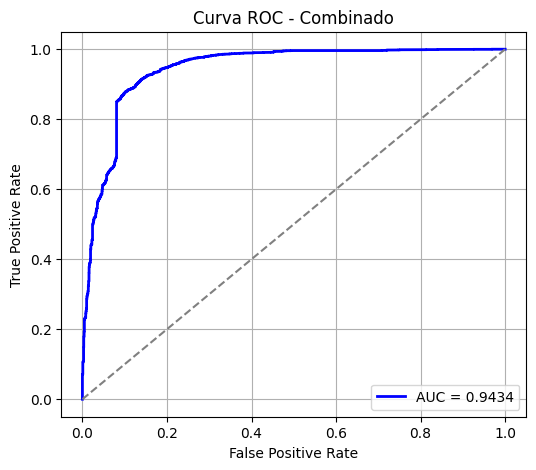

AUC: 0.9434

Validación cruzada 5 folds - Accuracy por fold: [0.78983944 0.78936017 0.7922192  0.79038185 0.78894392]
Promedio: 0.7901489183636909


In [ ]:
# Evaluar combinado
train_evaluate_svm(datasets["Combinado"], "Combinado")


===== Fourier =====

Accuracy : 0.8333
Precision: 0.8344
Recall   : 0.9678
F1-score : 0.8962

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.83      0.44      0.58       268
   PNEUMONIA       0.83      0.97      0.90       776

    accuracy                           0.83      1044
   macro avg       0.83      0.71      0.74      1044
weighted avg       0.83      0.83      0.81      1044



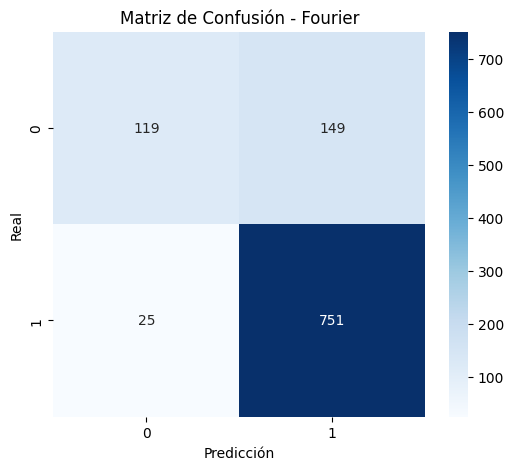

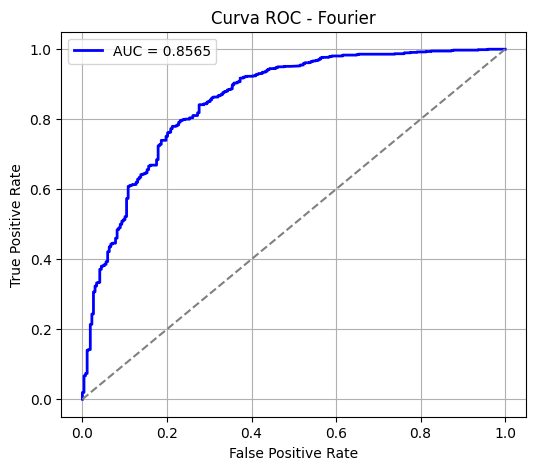

AUC: 0.8565

Validación cruzada 5 folds - Accuracy por fold: [0.80651341 0.7852349  0.79865772 0.7746884  0.77756472]
Promedio: 0.7885318286845712


In [ ]:
# Evaluar Fourier
train_evaluate_svm(datasets["Fourier"], "Fourier")


===== GLCM =====



/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2 3 4 5] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Accuracy : 0.7429
Precision: 0.7429
Recall   : 1.0000
F1-score : 0.8525

Classification Report


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00      3219
   PNEUMONIA       0.74      1.00      0.85      9300

    accuracy                           0.74     12519
   macro avg       0.37      0.50      0.43     12519
weighted avg       0.55      0.74      0.63     12519



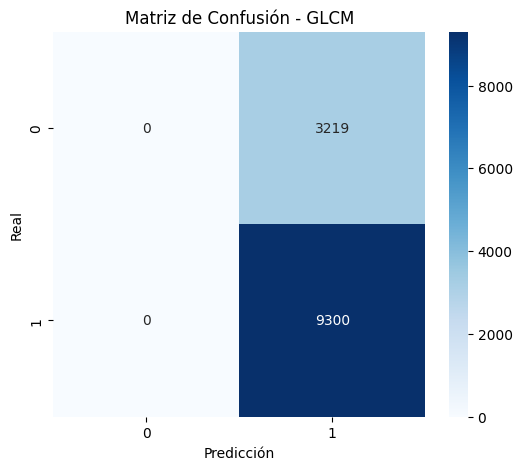

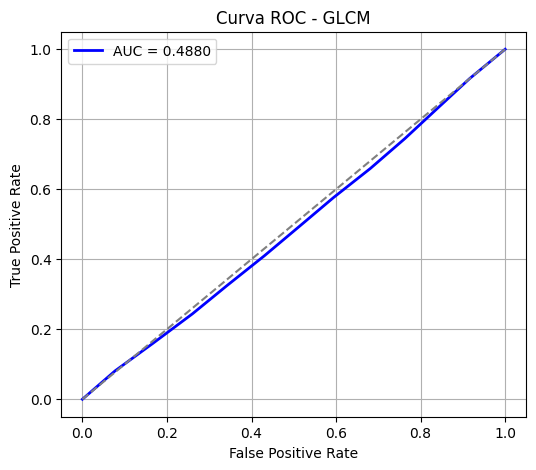

AUC: 0.4880

Validación cruzada 5 folds - Accuracy por fold: [0.74287084 0.74287084 0.74293018 0.74293018 0.74293018]
Promedio: 0.7429064428555255


In [ ]:
# Evaluar GLCM
train_evaluate_svm(datasets["GLCM"], "GLCM")